# Turbo codes: a shift register, two of them, and the iteration between

One pass through the second member of the repository's fourth problem class.
A rate-1/2 recursive systematic convolutional encoder is a linear feedback
shift register; its trellis is a hidden Markov chain whose state is the
register, so its exact decoder is forward--backward with the observation on
the edge (BCJR) and its maximum-likelihood decoder is max-product (Viterbi).
A turbo code is two of those fed the same message in two orders through an
interleaver, and its decoder is loopy sum-product on a serial schedule: two
BCJR passes exchanging extrinsic log-likelihood ratios.

Every number below is checked against something that shares no code with what
it checks --- enumeration over all `2 ** K` messages, the general sum-product
on the trellis factor graph, a parity-check matrix built by GF(2) nullspace,
or the uncoded closed form `Q(sqrt(2 E_b / N_0))`. The instances are the
fixture registry's, not this notebook's.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from snakes_and_ladders.likelihood.convolutional import (
    bcjr,
    exact_bitwise_posterior,
    viterbi,
)
from snakes_and_ladders.likelihood.ldpc import enumerate_codewords
from snakes_and_ladders.likelihood.message_passing import MessageSchedule, sum_product
from snakes_and_ladders.likelihood.turbo import (
    decode_turbo_per_iteration,
    exact_turbo_posterior,
    measure_error_rates,
    noise_scale,
    uncoded_bit_error_rate,
)
from snakes_and_ladders.qa.style import INK, INK_MUTED, notebook_style
from snakes_and_ladders.sim.convolutional import (
    encode_stream,
    inverse_permutation,
    octal_taps,
    parity_check,
    terminate,
    turbo_encode,
)
from snakes_and_ladders.sim.factor_graph import from_trellis
from snakes_and_ladders.sim.fixtures import fixture

SMALL = fixture("turbo", "ci").params
WATERFALL = fixture("turbo", "stress").params
print(f"enumerable instance: K = {SMALL.message_length}, seed {SMALL.seed}")
print(
    f"waterfall instance:  K = {WATERFALL.message_length}, {WATERFALL.frames} frames per point"
)

enumerable instance: K = 12, seed 233
waterfall instance:  K = 256, 50 frames per point


## 1. The register, and the trellis it is

The generators are octal and read most-significant bit first: `7` is
`1 + D + D**2` and `5` is `1 + D**2`, so the default register is
`[1, (1 + D**2) / (1 + D + D**2)]` with memory 2. Its state is the register
contents, four of them, with two edges leaving each. The tail is what makes
the trellis terminated at both ends, and for a *recursive* encoder it is a
function of the state rather than a string of zeros --- which is the one
detail that separates this from a feedforward code.

In [2]:
trellis = SMALL.trellis()
print(
    f"feedback  {SMALL.feedback:o} -> taps {octal_taps(SMALL.feedback, SMALL.memory).tolist()}"
)
print(
    f"feedforward {SMALL.feedforward:o} -> taps {octal_taps(SMALL.feedforward, SMALL.memory).tolist()}"
)
print(f"{trellis.n_states} states, next_state =\n{trellis.next_state}")
print(f"parity per edge =\n{trellis.parity}")
print(
    f"tail input per state = {trellis.tail_input.tolist()}  (zeros only for a feedforward code)"
)

rng = np.random.default_rng(1)
message = rng.integers(0, 2, SMALL.message_length).astype(np.uint8)
inputs = terminate(trellis, message)
parity, states = encode_stream(trellis, inputs)
print(f"\nmessage      {message.tolist()}")
print(f"with tail    {inputs.tolist()}")
print(f"states visited {states.tolist()}, final state {states[-1]}")

feedback  7 -> taps [1, 1, 1]
feedforward 5 -> taps [1, 0, 1]
4 states, next_state =
[[0 1]
 [3 2]
 [1 0]
 [2 3]]
parity per edge =
[[0 1]
 [1 0]
 [0 1]
 [1 0]]
tail input per state = [0, 1, 1, 0]  (zeros only for a feedforward code)

message      [0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
with tail    [0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0]
states visited [0, 0, 1, 2, 0, 0, 0, 1, 2, 1, 3, 3, 2, 0, 0], final state 0


## 2. Two registers, an interleaver, and one transmitted word

Both encoders are terminated, so a `K`-bit message transmits `3K + 4m` bits:
the first encoder's input stream (message then tail), its parity, the second
encoder's tail inputs, and its parity. The second encoder's message bits are
already in the first's systematic stream, in the interleaver's order.

The interleaver is drawn from the fixture's seed, and its inverse composes to
the identity --- the property everything downstream rests on, since the
extrinsic exchange permutes and unpermutes on every half-iteration.

In [3]:
code_ = SMALL.code()
where = code_.slices()
print(
    f"K = {code_.message_length}, m = {code_.trellis.memory}, n = {code_.block_length}, rate = {code_.rate:.4f}"
)
print({name: (span.start, span.stop) for name, span in where.items()})

order = code_.interleaver
inverse = inverse_permutation(order)
print(f"\ninterleaver {order.tolist()}")
print(f"inverse     {inverse.tolist()}")
print(
    f"order[inverse] is the identity: {np.array_equal(order[inverse], np.arange(order.size))}"
)
print(
    f"inverse[order] is the identity: {np.array_equal(inverse[order], np.arange(order.size))}"
)

word = turbo_encode(code_, message)
print(f"\nword          {word.tolist()}")
print(
    f"systematic part equals the message with its tail: {np.array_equal(word[where['systematic']], inputs)}"
)

K = 12, m = 2, n = 44, rate = 0.2727
{'systematic': (0, 14), 'parity_first': (14, 28), 'tail_second': (28, 30), 'parity_second': (30, 44)}

interleaver [4, 8, 7, 9, 0, 10, 2, 5, 11, 6, 1, 3]
inverse     [4, 10, 6, 11, 0, 7, 9, 2, 1, 3, 5, 8]
order[inverse] is the identity: True
inverse[order] is the identity: True

word          [0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0]
systematic part equals the message with its tail: True


## 3. The same code, as a parity-check matrix

A convolutional code is linear, so it is the null space of some `H`. Building
one by GF(2) nullspace and enumerating its codewords with the parity-check
machinery gives a set that never saw the shift register --- and it is the
same set the encoder produces. This is what makes the encoder pinned rather
than asserted, and it is why a turbo instance is also an instance of the
parity-check problem class.

In [4]:
check = parity_check(code_)
print(
    f"H is {check.n_checks} x {check.n_bits}, {check.n_edges} nonzeros (dense, not low-density)"
)
print(f"syndrome of the encoded word is zero: {not np.any(check.syndrome(word))}")

from_h = {row.tobytes() for row in enumerate_codewords(check)}
from_encoder = {
    turbo_encode(code_, m).tobytes()
    for m in (
        (np.arange(2**code_.message_length)[:, None] >> np.arange(code_.message_length))
        & 1
    ).astype(np.uint8)
}
print(
    f"{len(from_h)} codewords from H, {len(from_encoder)} from the encoder, identical: {from_h == from_encoder}"
)

H is 32 x 44, 216 nonzeros (dense, not low-density)
syndrome of the encoded word is zero: True


4096 codewords from H, 4096 from the encoder, identical: True


## 4. BCJR against enumeration, and against the general sum-product

One constituent code is a chain, so message passing on it is exact and
equality may be asserted rather than a departure reported. Two referees say
different things: enumerating all `2 ** K` messages says the posterior is
*right*; the tree schedule of the repository's general `sum_product`, run on
the factor graph `from_trellis` builds, says this specialization is the *same
computation* as the one every other problem class here runs.

In [5]:
sigma = noise_scale(1.0, 0.5)
noise_rng = np.random.default_rng(7)
received = (
    1.0 - 2.0 * np.concatenate([inputs, parity])
) + sigma * noise_rng.standard_normal(2 * inputs.size)
llr = 2.0 * received / sigma**2
systematic_llr, parity_llr = llr[: inputs.size], llr[inputs.size :]

decoding = bcjr(trellis, systematic_llr, parity_llr)
exact = exact_bitwise_posterior(
    trellis, systematic_llr, parity_llr, SMALL.message_length
)
gap = np.abs(decoding.posterior_llr[: SMALL.message_length] - exact.posterior_llr).max()
print(
    f"BCJR against enumeration over 2**{SMALL.message_length} messages: {gap:.2e} in log-odds"
)
print(f"evidence: {decoding.log_evidence:.6f} against {exact.log_evidence:.6f}")

graph = from_trellis(trellis, systematic_llr, parity_llr)
print(f"\nthe trellis factor graph is a tree: {graph.is_tree()}")
marginals = sum_product(graph, schedule=MessageSchedule.TREE)
states = np.arange(trellis.n_states)
from_graph = np.array(
    [
        np.log(
            marginals.factor[f"T{t}"][states, trellis.next_state[:, 0]].sum()
            / marginals.factor[f"T{t}"][states, trellis.next_state[:, 1]].sum()
        )
        for t in range(systematic_llr.size)
    ]
)
print(
    f"BCJR against the tree schedule: {np.abs(from_graph - decoding.posterior_llr).max():.2e} in log-odds"
)
print(f"log Z: {marginals.log_partition:.10f} against {decoding.log_evidence:.10f}")

BCJR against enumeration over 2**12 messages: 1.35e-13 in log-odds
evidence: 39.767463 against 39.767463

the trellis factor graph is a tree: True
BCJR against the tree schedule: 1.07e-14 in log-odds
log Z: 39.7674628551 against 39.7674628551


## 5. Two decodings of one trellis, and they are different answers

BCJR's hard decision is the *bitwise* MAP, each bit at the mode of its own
marginal; Viterbi's is the *blockwise* MAP, the single most likely message.
They agree on almost every received word, which is exactly why a decoder that
computes one and reports the other survives a suite with no case where they
diverge. Here is a word where they do.

In [6]:
diverging_rng = np.random.default_rng(2)
short = diverging_rng.integers(0, 2, 8).astype(np.uint8)
short_inputs = terminate(trellis, short)
short_parity, _ = encode_stream(trellis, short_inputs)
noisy_sigma = 1.6
noisy = (
    1.0 - 2.0 * np.concatenate([short_inputs, short_parity])
) + noisy_sigma * diverging_rng.standard_normal(2 * short_inputs.size)
noisy_llr = 2.0 * noisy / noisy_sigma**2
short_s, short_p = noisy_llr[: short_inputs.size], noisy_llr[short_inputs.size :]

short_exact = exact_bitwise_posterior(trellis, short_s, short_p, 8)
bitwise = (short_exact.posterior_llr < 0).astype(np.uint8)
print(f"sent           {short.tolist()}")
print(f"bitwise MAP    {bitwise.tolist()}")
print(
    f"blockwise MAP  {short_exact.ml_message.tolist()}  (Viterbi: {viterbi(trellis, short_s, short_p)[:8].tolist()})"
)
print(f"they differ: {not np.array_equal(bitwise, short_exact.ml_message)}")
print(
    f"margin over the runner-up: {short_exact.margin:.4f} nats, so no tie is being broken"
)

sent           [1, 0, 0, 0, 0, 1, 0, 0]
bitwise MAP    [0, 0, 0, 0, 0, 1, 0, 0]
blockwise MAP  [1, 0, 0, 0, 0, 1, 0, 0]  (Viterbi: [1, 0, 0, 0, 0, 1, 0, 0])
they differ: True
margin over the runner-up: 0.8508 nats, so no tie is being broken


## 6. The turbo iteration, against the exact bitwise MAP

The joint graph has cycles, so the iteration is the Bethe approximation and
equality against the exact answer would be a false claim. What is measured
instead is the gap: how far the iteration's bit error rate falls from its
first iteration, and how close it gets to the exact bitwise MAP's. At
`K = 12` the interleaver is far too short to close it.

In [7]:
gap_rng = np.random.default_rng(SMALL.seed)
exact_errors = 0
iteration_errors = np.zeros(SMALL.iterations, dtype=np.int64)
point = 1.0
turbo_sigma = noise_scale(point, code_.rate)
for _ in range(SMALL.frames):
    draw = gap_rng.integers(0, 2, SMALL.message_length).astype(np.uint8)
    sent = turbo_encode(code_, draw)
    y = (1.0 - 2.0 * sent) + turbo_sigma * gap_rng.standard_normal(code_.block_length)
    ratios = 2.0 * y / turbo_sigma**2
    exact_errors += int((exact_turbo_posterior(code_, ratios).bits != draw).sum())
    iteration_errors += (
        decode_turbo_per_iteration(code_, ratios, iterations=SMALL.iterations)
        != draw[None, :]
    ).sum(axis=1)

bits = SMALL.frames * SMALL.message_length
print(f"at {point:g} dB over {SMALL.frames} frames ({bits} message bits)")
print(f"exact bitwise MAP     {exact_errors / bits:.5f}")
for index, errors in enumerate(iteration_errors, start=1):
    print(f"turbo, {index} iteration{'s' if index > 1 else ' '}    {errors / bits:.5f}")
print(
    f"\nratio at {SMALL.iterations} iterations: {iteration_errors[-1] / exact_errors:.2f} times the exact MAP"
)
print(f"uncoded at {point:g} dB: {uncoded_bit_error_rate(np.array([point]))[0]:.5f}")

at 1 dB over 100 frames (1200 message bits)
exact bitwise MAP     0.03667
turbo, 1 iteration     0.07500
turbo, 2 iterations    0.06917
turbo, 3 iterations    0.05583
turbo, 4 iterations    0.06167
turbo, 5 iterations    0.05583
turbo, 6 iterations    0.06000
turbo, 7 iterations    0.05250
turbo, 8 iterations    0.06083

ratio at 8 iterations: 1.66 times the exact MAP
uncoded at 1 dB: 0.05628


The last two lines are the finding a short block makes visible: at `K = 12`
the code is barely better than sending the bits uncoded. The interleaver gain
is what a turbo code buys and it grows with the block length, so the
waterfall is measured at `K = 256` instead.

## 7. The waterfall

Bit error rate against `E_b / N_0` at four iteration counts, on the declared
`K = 256` instance, beside the uncoded antipodal closed form
`Q(sqrt(2 E_b / N_0))` --- the reference every coded curve must fall below.
Each point rests on the fixture's frame count, and the number is stated
rather than left to the reader, because a curve without it bounds nothing.

In [8]:
waterfall_code = WATERFALL.code()
rates = [
    measure_error_rates(
        waterfall_code,
        db,
        WATERFALL.frames,
        np.random.default_rng(WATERFALL.seed),
        iterations=WATERFALL.iterations,
    )
    for db in WATERFALL.eb_n0_db
]
points = np.array(WATERFALL.eb_n0_db)
uncoded = uncoded_bit_error_rate(points)
per_point = np.array([rate.bit_error_rate for rate in rates])
print(f"{rates[0].frames} frames and {rates[0].bits} message bits per point\n")
print("E_b/N_0   " + "  ".join(f"it {i:<2}" for i in (1, 2, 4, 8)) + "   uncoded")
for db, row, u in zip(points, per_point, uncoded, strict=True):
    cells = "  ".join(f"{row[i - 1]:.4f}" for i in (1, 2, 4, 8))
    print(f"{db:>6.1f}   {cells}   {u:.4f}")
print(
    f"\ncoded below uncoded at every point: {bool(np.all(per_point[:, -1] < uncoded))}"
)
print(f"falls with E_b/N_0: {bool(np.all(np.diff(per_point[:, -1]) <= 0))}")

50 frames and 12800 message bits per point

E_b/N_0   it 1   it 2   it 4   it 8    uncoded
   0.0   0.1313  0.0970  0.0766  0.0739   0.0786
   0.4   0.1018  0.0619  0.0444  0.0419   0.0693
   0.8   0.0758  0.0362  0.0233  0.0173   0.0605
   1.2   0.0539  0.0184  0.0075  0.0060   0.0522
   1.6   0.0372  0.0088  0.0014  0.0000   0.0445
   2.0   0.0235  0.0013  0.0000  0.0000   0.0375

coded below uncoded at every point: True
falls with E_b/N_0: True


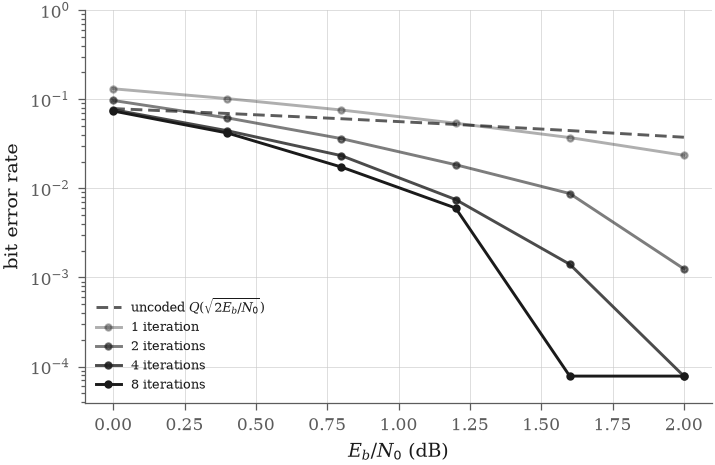

In [9]:
floor = 1.0 / rates[0].bits
with notebook_style():
    fig, ax = plt.subplots(figsize=(5.4, 3.4))
    ax.plot(
        points,
        uncoded,
        color=INK_MUTED,
        linestyle=(0, (4, 2)),
        label="uncoded $Q(\\sqrt{2E_b/N_0})$",
    )
    for index, iteration in enumerate((1, 2, 4, 8)):
        values = per_point[:, iteration - 1]
        ax.plot(
            points,
            np.where(values <= 0, floor, values),
            color=INK,
            alpha=0.35 + 0.65 * index / 3,
            marker="o",
            markersize=3,
            label=f"{iteration} iteration" + ("s" if iteration > 1 else ""),
        )
    ax.set_yscale("log")
    ax.set_ylim(floor * 0.5, 1.0)
    ax.set_xlabel("$E_b / N_0$ (dB)")
    ax.set_ylabel("bit error rate")
    ax.legend(fontsize=6, frameon=False, loc="lower left")
    plt.show()

## 8. Where the iteration departs

The strong claim --- that each iteration improves on the last --- is not one
the measurement supports. The rises below are all inside one binomial
interval of the sample, so what the data says is *no worse*, not *better*,
and the suite asserts only the weak form.

In [10]:
for db, rate in zip(points, rates, strict=True):
    rise = np.diff(rate.bit_error_rate)
    worst = rise.max()
    interval = rate.bit_error_interval[-1]
    where_worst = int(np.argmax(rise)) + 1
    if worst > 0:
        print(
            f"{db:>4.1f} dB  largest rise {worst:.2e} between iterations "
            f"{where_worst} and {where_worst + 1}, against a one-sigma interval of {interval:.2e}"
        )
    else:
        print(f"{db:>4.1f} dB  monotone over all {WATERFALL.iterations} iterations")

 0.0 dB  largest rise 2.34e-03 between iterations 7 and 8, against a one-sigma interval of 2.31e-03
 0.4 dB  largest rise 3.13e-04 between iterations 4 and 5, against a one-sigma interval of 1.77e-03
 0.8 dB  largest rise 1.09e-03 between iterations 5 and 6, against a one-sigma interval of 1.15e-03
 1.2 dB  largest rise 3.91e-04 between iterations 4 and 5, against a one-sigma interval of 6.83e-04
 1.6 dB  monotone over all 8 iterations
 2.0 dB  monotone over all 8 iterations


## Further work

What this notebook could not demonstrate, because the feature is not built.
Each line names the issue that carries it.

- **Puncturing to rate 1/2 and the LTE interleaver (#233).** The code here is
  rate-1/3 unpunctured with a uniformly random interleaver. The quadratic
  permutation polynomial LTE specifies, and the puncturing pattern that
  raises the rate, are the two pieces a standards-conformant instance needs;
  neither changes any decoder here, and both change the waterfall.
- **The memory-3 `(13, 15)` register at size (#233).** `sim.convolutional`
  builds it and the suite pins its trellis and its tail, but every measured
  curve above is the memory-2 `(7, 5)`. Eight states rather than four doubles
  the BCJR's inner loop and is worth roughly 0.3 dB; nothing here measures
  that.
- **Turbo decoding as optimization, and a learned schedule (#360).** The
  serial schedule is a choice. Neural belief propagation over the turbo
  graph --- learned weights on the extrinsic exchange --- is #360's proposal
  and is out of scope here; the `Fit`, `Search` and `Learn` columns of this
  problem's `PROBLEMS.md` row are empty for that reason.
- **A Rust BCJR kernel (#233).** The decoder is NumPy over a four-state
  trellis with a Python loop per step, which is the shape a compiled backend
  wins on. No port is proposed until a profile says the loop dominates and a
  measurement through the binding says the boundary does not eat the win.